## Table of Contents

## 1. Obtain a dataset and frame the predictive problem
- [1.1 Standardize Column Names](#1.1-Standardize-Column-Names)
- [1.2 Basic Checks](#1.2-Basic-Checks)
- [1.3 Drop Obvious ID Columns](#1.3-Drop-Obvious-ID-Columns)
- [1.4 Ensure Target Exists and Is Binary](#1.4-Ensure-Target-Exists-and-Is-Binary)
- [1.5 Missing Summary](#1.5-Missing-Summary)
- [1.6 Target Distribution](#1.6-Target-Distribution)
- [1.7 Column Type Summary](#1.7-Column-Type-Summary)
- [1.8 Numeric Sanity Checks](#1.8-Numeric-Sanity-Checks)

## 2. Explore the data to gain insights
- [2.1 Dataset Overview](#2.1-Dataset-Overview)
- [2.2 Target Balance](#2.2-Target-Balance)
- [2.3 Missingness](#2.3-Missingness)
- [2.4 Leakage Risk Screening](#2.4-Leakage-Risk-Screening)
- [2.5 Numeric Feature Profile](#2.5-Numeric-Feature-Profile)
- [2.6 Categorical vs Churn](#2.6-Categorical-vs-Churn)
- [2.7 Numeric vs Churn](#2.7-Numeric-vs-Churn)
- [2.8 Outlier Diagnostics (IQR)](#2.8-Outlier-Diagnostics-(IQR))
- [2.9 Quick Risk Flags](#2.9-Quick-Risk-Flags)
- [2.10 Numeric Correlation with Target](#2.10-Numeric-Correlation-with-Target)

## 3. Prepare the data
- [3.1 Load cleaned/base data](#3.1-Load-cleaned/base-data)
- [3.2 Standardize columns](#3.2-Standardize-columns)
- [3.3 Confirmed leakage interface](#3.3-Confirmed-leakage-interface)
- [3.4 Drop ID-like cols](#3.4-Drop-ID-like-cols)
- [3.5 Validate target](#3.5-Validate-target)
- [3.6 Clean object cols](#3.6-Clean-object-cols)
- [3.7 Define features and target](#3.7-Define-features-and-target)
- [3.8 Stratified split (70/15/15)](#3.8-Stratified-split-(70/15/15))
- [3.9 Feature Types from Train](#3.9-Feature-Types-from-Train)
- [3.10 Train-only constant drop](#3.10-Train-only-constant-drop)
- [3.11 Leakage-risk keyword scan](#3.11-Leakage-risk-keyword-scan)
- [3.12 Feature typing](#3.12-Feature-typing)
- [3.13 Preprocessor](#3.13-Preprocessor)
- [3.14 Preprocess output audit via clone(preprocessor)](#3.14-Preprocess-output-audit-via-clone(preprocessor))
- [3.15 Save split artifacts with index](#3.15-Save-split-artifacts-with-index)
- [3.16 Run manifest](#3.16-Run-manifest)

## 4. Explore different models and shortlist the best ones
- [4.1 Candidate model pipelines](#4.1-Candidate-model-pipelines)
- [4.2 Validation comparison](#4.2-Validation-comparison)
- [4.3 Shortlist model using validation evidence](#4.3-Shortlist-model-using-validation-evidence)

## 5. Fine-tune and evaluate
- [5.1 Tuning strategy](#5.1-Tuning-strategy)
- [5.2 Locked final test evaluation](#5.2-Locked-final-test-evaluation)
- [5.3 Error analysis: decile lift / gains](#5.3-Error-analysis:-decile-lift-/-gains)
- [5.4 Error analysis: calibration](#5.4-Error-analysis:-calibration)
- [5.5 Save key outputs](#5.5-Save-key-outputs)

## 6. Present the final solution
- [6.1 Final solution](#6.1-Final-solution)

In [1719]:
# Global imports
import os
import re
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from datetime import datetime
from scipy import sparse

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier

# Global constants
RANDOM_SEED = 42
DATA_PATH = "../data/Telecom_customer churn.csv"
TARGET_COL = "churn"
HIGH_MISSING_THRESHOLD = 40
OUTPUT_DIR = "../results"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/splits", exist_ok=True)


In [1720]:
file_path = "../data/Telecom_customer churn.csv"
df = pd.read_csv(file_path)


## 1. Obtain a dataset and frame the predictive problem
This project predicts customer churn using a supervised binary classification setup, where `churn=1` means the customer is likely to leave. The dataset is a telecom customer-level table with mixed numerical and categorical features. The practical objective is to support retention intervention by identifying high-risk customers early.

Success is evaluated with both ranking metrics and operating-point metrics. ROC-AUC and PR-AUC are used for ranking quality; Precision, Recall, and F1 are used for intervention trade-offs at a selected threshold. Main constraints are reproducibility, leakage control, and transparent validation. Agent support was used for code scaffolding and checks, while all key modeling and data decisions were manually verified.


### 1.1 Standardize Column Names
Column names are normalized to a consistent snake_case format to reduce naming ambiguity and prevent downstream feature-selection bugs.

In [1721]:
# 1.1 Standardize column names
def standardize_col(col: str) -> str:
    col = col.strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

df.columns = [standardize_col(c) for c in df.columns]

### 1.2 Basic Checks
Initial checks confirm dataset shape, dtypes, sample records, and duplicate count to establish a reliable baseline before transformation.

In [1722]:
# 1.2 Basic checks
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nHead:")
print(df.head())
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (100000, 100)

Dtypes:
rev_mean       float64
mou_mean       float64
totmrc_mean    float64
da_mean        float64
ovrmou_mean    float64
                ...   
kid11_15        object
kid16_17        object
creditcd        object
eqpdays        float64
customer_id      int64
Length: 100, dtype: object

Head:
   rev_mean  mou_mean  totmrc_mean  da_mean  ovrmou_mean  ovrrev_mean  \
0   23.9975    219.25       22.500   0.2475         0.00          0.0   
1   57.4925    482.75       37.425   0.2475        22.75          9.1   
2   16.9900     10.25       16.990   0.0000         0.00          0.0   
3   38.0000      7.50       38.000   0.0000         0.00          0.0   
4   55.2300    570.50       71.980   0.0000         0.00          0.0   

   vceovr_mean  datovr_mean  roam_mean  change_mou  ...  forgntvl  ethnic  \
0          0.0          0.0        0.0     -157.25  ...       0.0       N   
1          9.1          0.0        0.0      532.25  ...       0.0       Z   
2          0.

### 1.3 Drop Obvious ID Columns
Identifier-like columns are removed to avoid memorization behavior and leakage-like shortcuts that do not generalize.

In [1723]:
# 1.3 Drop Obvious ID Columns (aligned with Step 3)
target_candidates = ["churn", "target", "label"]
target_col = next((c for c in target_candidates if c in df.columns), None)

id_candidates = [
    c for c in df.columns
    if (
        c.lower() == "id" or c.lower().endswith("_id")
    ) and (target_col is None or c != target_col)
]

print("\nDetected ID-like column(s):", id_candidates if id_candidates else "None")

if id_candidates:
    df = df.drop(columns=id_candidates, errors="ignore")




Detected ID-like column(s): ['customer_id']


### 1.4 Ensure Target Exists and Is Binary
The target column is validated for presence and binary consistency. Any invalid target encoding is handled before modeling.

In [1724]:
# 1.4 Ensure target exists and is binary
target_candidates = ["churn", "target", "label"]
target_col = next((c for c in target_candidates if c in df.columns), None)
if target_col is None:
    raise ValueError(f"Target column not found. Looked for: {target_candidates}")

# Normalize common churn labels to 0/1
if df[target_col].dtype == "O":
    s = df[target_col].astype(str).str.strip().str.lower()
    mapping = {
        "yes": 1, "no": 0,
        "true": 1, "false": 0,
        "1": 1, "0": 0
    }
    mapped = s.map(mapping)
    if mapped.notna().all():
        df[target_col] = mapped.astype("int8")

unique_vals = sorted(df[target_col].dropna().unique().tolist())
if set(unique_vals) != {0, 1}:
    raise ValueError(f"Target '{target_col}' is not binary after normalization. Unique values: {unique_vals}")

print(f"\nTarget column: '{target_col}' (binary confirmed)")



Target column: 'churn' (binary confirmed)


### 1.5 Missing Summary
Missingness is profiled per column to identify data quality risk and to inform imputation strategy in preprocessing.

In [1725]:
# 1.5 Missing summary
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
      .sort_values("missing_count", ascending=False)
)
print("\nMissing summary:")
print(missing[missing["missing_count"] > 0] if (missing["missing_count"] > 0).any() else "No missing values.")

high_missing_cols = missing[missing["missing_pct"] > 40].index.tolist()
print("\nHigh missing columns (>40%):", high_missing_cols if high_missing_cols else "None")



Missing summary:
                  missing_count  missing_pct
numbcars                  49366        49.37
dwllsize                  38308        38.31
hhstatin                  37923        37.92
ownrent                   33706        33.71
dwlltype                  31909        31.91
lor                       30190        30.19
income                    25436        25.44
adults                    23019        23.02
infobase                  22079        22.08
hnd_webcap                10189        10.19
prizm_social_one           7388         7.39
avg6qty                    2839         2.84
avg6rev                    2839         2.84
avg6mou                    2839         2.84
kid6_10                    1732         1.73
kid16_17                   1732         1.73
rv                         1732         1.73
kid3_5                     1732         1.73
marital                    1732         1.73
creditcd                   1732         1.73
kid11_15                   1732      

### 1.6 Target Distribution
Class balance is inspected to quantify imbalance and justify metric choices beyond simple accuracy.

In [1726]:
# 1.6 Target distribution
target_dist = (
    df[target_col]
      .value_counts(dropna=False)
      .rename_axis(target_col)
      .to_frame("count")
)
target_dist["pct"] = (target_dist["count"] / len(df) * 100).round(2)
print("\nTarget distribution:")
print(target_dist)


Target distribution:
       count    pct
churn              
0      50438  50.44
1      49562  49.56


### 1.7 Column Type Summary
Numerical and categorical feature groups are summarized to design an appropriate preprocessing pipeline.

In [1727]:
# 1.7 Column type summary
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print("\nNumeric columns count:", len(numeric_cols))
print("Categorical columns count:", len(categorical_cols))
print("\nNumeric columns (first 20):", numeric_cols[:20])
print("\nCategorical columns (first 20):", categorical_cols[:20])


Numeric columns count: 78
Categorical columns count: 21

Numeric columns (first 20): ['rev_mean', 'mou_mean', 'totmrc_mean', 'da_mean', 'ovrmou_mean', 'ovrrev_mean', 'vceovr_mean', 'datovr_mean', 'roam_mean', 'change_mou', 'change_rev', 'drop_vce_mean', 'drop_dat_mean', 'blck_vce_mean', 'blck_dat_mean', 'unan_vce_mean', 'unan_dat_mean', 'plcd_vce_mean', 'plcd_dat_mean', 'recv_vce_mean']

Categorical columns (first 20): ['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'hhstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17']


### 1.8 Numeric Sanity Checks
Numeric columns are checked for invalid values (NaN/inf/extreme ranges) to ensure stable downstream processing.

In [1728]:
# 1.8 Numeric sanity checks
if numeric_cols:
    num_df = df[numeric_cols].copy()

    sanity = pd.DataFrame(index=num_df.columns)
    sanity["missing_count"] = num_df.isna().sum()
    sanity["missing_pct"] = (sanity["missing_count"] / len(df) * 100).round(2)

    # Column-stable inf count (exactly follows num_df column order); NaN is not counted as inf
    inf_count = np.isinf(num_df.to_numpy(dtype="float64")).sum(axis=0)
    sanity["inf_count"] = pd.Series(inf_count, index=num_df.columns)

    sanity["zero_count"] = (num_df == 0).sum()
    sanity["negative_count"] = (num_df < 0).sum()
    sanity["n_unique"] = num_df.nunique(dropna=True)
    sanity["min"] = num_df.min(numeric_only=True)
    sanity["max"] = num_df.max(numeric_only=True)

    print("\nNumeric sanity checks:")
    print(sanity.sort_values(["missing_count", "inf_count", "negative_count"], ascending=False))

    constant_cols = sanity[sanity["n_unique"] <= 1].index.tolist()
    print("\nConstant numeric columns (<=1 unique):", constant_cols if constant_cols else "None")



Numeric sanity checks:
          missing_count  missing_pct  inf_count  zero_count  negative_count  \
numbcars          49366        49.37          0           0               0   
lor               30190        30.19          0        2193               0   
income            25436        25.44          0           0               0   
adults            23019        23.02          0           0               0   
avg6rev            2839         2.84          0           0               3   
...                 ...          ...        ...         ...             ...   
avgmou                0         0.00          0          36               0   
avgqty                0         0.00          0          36               0   
avg3mou               0         0.00          0        1761               0   
avg3qty               0         0.00          0        1845               0   
avg3rev               0         0.00          0           0               0   

          n_unique  min    

## 2. Explore the data to gain insights
EDA is conducted to identify patterns relevant to churn and to detect risks before modeling. The section covers distributions, missingness, leakage screening, class imbalance, and outlier diagnostics. Visualizations are concise and decision-oriented rather than exhaustive. Key goals are to detect likely modeling pitfalls (heavy skew, rare categories, potential leakage fields, high-cardinality features) and translate findings into preparation choices. Agent-suggested plots were manually checked for correctness before inclusion.


In [1729]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Ensure helper lists are up to date after cleaning
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in df.select_dtypes(exclude=["number"]).columns if c != target_col]


### 2.1 Dataset Overview
A compact schema/profile table is used to summarize feature availability, types, and cardinality.

In [1730]:
# 2.1: Dataset Overview
print("\nDataset Overview")
print("Rows:", len(df), "| Columns:", df.shape[1])
print("Target:", target_col)
print("Numeric cols:", len(numeric_cols), "| Categorical cols:", len(categorical_cols))


Dataset Overview
Rows: 100000 | Columns: 99
Target: churn
Numeric cols: 78 | Categorical cols: 21


### 2.2 Target Balance
Class proportions are visualized to confirm imbalance level and motivate recall/PR-aware evaluation.


Target Balance
       count    pct
churn              
0      50438  50.4%
1      49562  49.6%


/var/folders/nx/tlgm1jmn5j72nft556p0gd640000gn/T/ipykernel_24575/3531949187.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


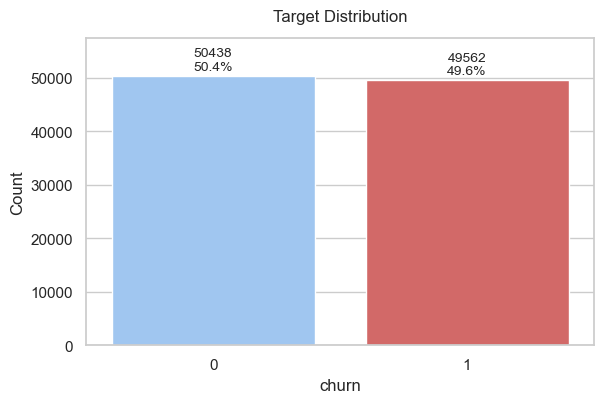

In [1731]:
# 2.2: Target Balance
print("\nTarget Balance")
target_counts = df[target_col].value_counts(dropna=False).sort_index()
target_pct = (target_counts / len(df) * 100)

target_summary = pd.DataFrame({
    "count": target_counts,
    "pct": target_pct.map(lambda v: f"{v:.1f}%")
})
print(target_summary)

plt.figure(figsize=(6.2, 4.2))
ax = sns.barplot(
    x=target_counts.index.astype(str),
    y=target_counts.values,
    palette=["#93c5fd", "#E45756"]
)

upper = target_counts.max() * 1.14
ax.set_ylim(0, upper)

for i, (cnt, pct) in enumerate(zip(target_counts.values, target_pct.values)):
    ax.text(i, cnt + target_counts.max() * 0.01, f"{cnt}\n{pct:.1f}%", ha="center", va="bottom", fontsize=10)

plt.title("Target Distribution", pad=12)
plt.xlabel(target_col)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 2.3 Missingness
Missing-value counts/rates are inspected to decide whether columns need imputation or exclusion rules.


 Missingness
                  missing_count  missing_pct
numbcars                  49366        49.37
dwllsize                  38308        38.31
hhstatin                  37923        37.92
ownrent                   33706        33.71
dwlltype                  31909        31.91
lor                       30190        30.19
income                    25436        25.44
adults                    23019        23.02
infobase                  22079        22.08
hnd_webcap                10189        10.19
prizm_social_one           7388         7.39
avg6qty                    2839         2.84
avg6rev                    2839         2.84
avg6mou                    2839         2.84
kid6_10                    1732         1.73
kid16_17                   1732         1.73
rv                         1732         1.73
kid3_5                     1732         1.73
marital                    1732         1.73
creditcd                   1732         1.73


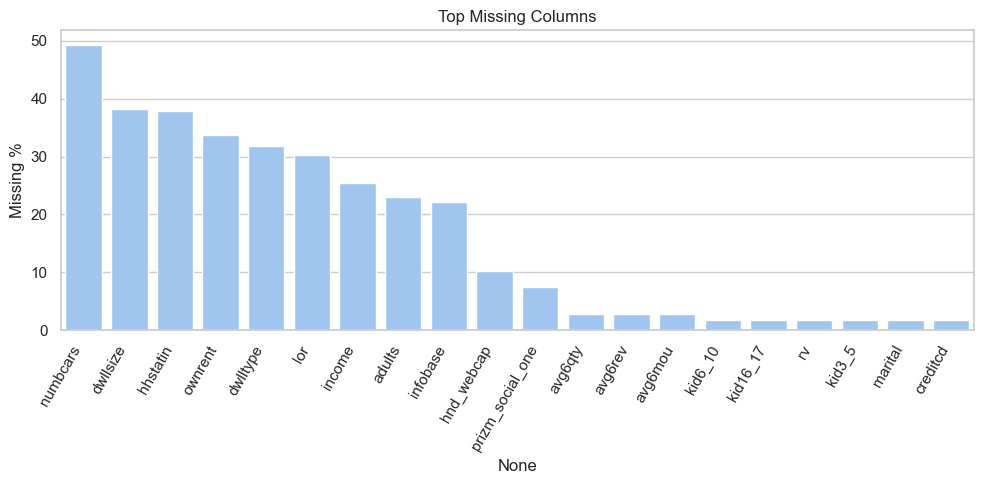

In [1732]:
# 2.3: Missingness
print("\n Missingness")
missing_tbl = (
    df.isna().sum().to_frame("missing_count")
      .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
      .sort_values("missing_count", ascending=False)
)
print(missing_tbl.head(20))

missing_nonzero = missing_tbl[missing_tbl["missing_count"] > 0].head(20)
if not missing_nonzero.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_nonzero.index, y=missing_nonzero["missing_pct"], color="#93c5fd")
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Missing %")
    plt.title("Top Missing Columns")
    plt.tight_layout()
    plt.show()


### 2.4 Leakage Risk Screening
Keyword-based screening is used at EDA stage to flag potential leakage/identifier columns for later enforcement in preprocessing.

In [1733]:
# 2.4 Leakage Risk Screening (EDA stage)
print("\n Leakage Risk Screening")
# Screening only in EDA; enforcement is done later in preprocessing
leak_keywords = ("id", "customer", "account", "phone", "target", "churn")

suspect_cols_eda = sorted({
    c for c in df.columns
    if c != target_col and any(k in c.lower() for k in leak_keywords)
})

print("Potential leakage-risk columns (keyword scan):")
print(suspect_cols_eda if suspect_cols_eda else "None")

print("\nManual review note:")
print("Leakage-risk screening is performed in EDA.")
print("Identifier-like fields were later removed during preprocessing.")
print("No confirmed post-outcome leakage feature was retained for modeling.")



 Leakage Risk Screening
Potential leakage-risk columns (keyword scan):
['kid0_2', 'kid11_15', 'kid16_17', 'kid3_5', 'kid6_10', 'phones']

Manual review note:
Leakage-risk screening is performed in EDA.
Identifier-like fields were later removed during preprocessing.
No confirmed post-outcome leakage feature was retained for modeling.


### 2.5 Numeric Feature Profile
Representative numeric distributions are reviewed (with visualization clipping only) to improve readability under heavy tails.


 Numeric Feature Profile
Note: percentile clipping below is for visualization only. Full values are used in modeling.


                  count        mean         std        min        1%  \
rev_mean        99643.0   58.719985   46.291677    -6.1675   10.0000   
mou_mean        99643.0  513.559937  525.168140     0.0000    0.0000   
totmrc_mean     99643.0   46.179136   23.623489   -26.9150    7.7446   
da_mean         99643.0    0.888828    2.177619     0.0000    0.0000   
ovrmou_mean     99643.0   41.072247   97.296150     0.0000    0.0000   
ovrrev_mean     99643.0   13.559560   30.500885     0.0000    0.0000   
vceovr_mean     99643.0   13.295062   30.056089     0.0000    0.0000   
datovr_mean     99643.0    0.261318    3.126531     0.0000    0.0000   
roam_mean       99643.0    1.286405   14.711374     0.0000    0.0000   
change_mou      99109.0  -13.933818  276.087509 -3875.0000 -835.9800   
change_rev      99109.0   -1.021067   50.363209 -1107.7400 -104.5743   
drop_vce_mean  100000.0    5.955085    8.954715     0.0000    0.0000   
drop_dat_mean  100000.0    0.040520    0.877136     0.0000    0.

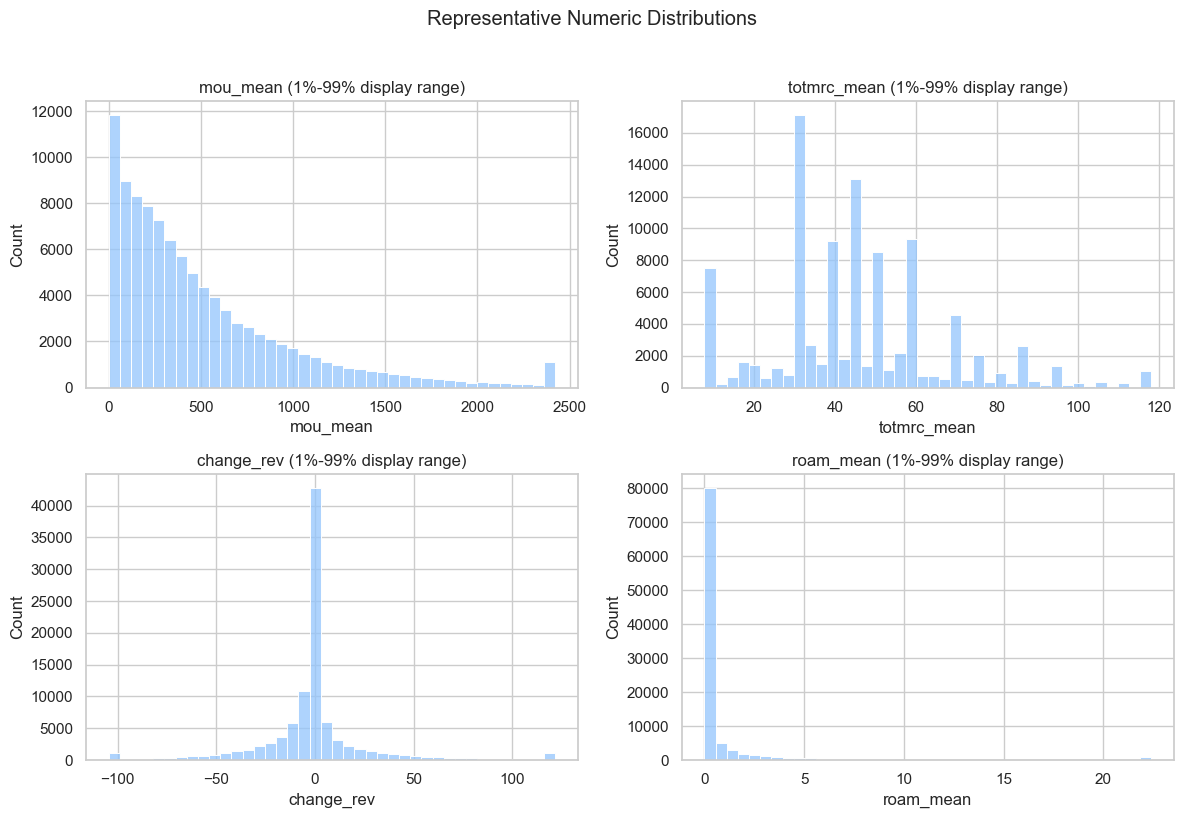

In [1734]:
# 2.5 Numeric Feature Profile

print("\n Numeric Feature Profile")
print("Note: percentile clipping below is for visualization only. Full values are used in modeling.")

if numeric_cols:
    # 1) Numeric summary table (audit-friendly)
    desc = df[numeric_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
    print(desc.head(20))

    # 2) Representative distributions (1%-99% display range only)
    rep_vars = [c for c in ["mou_mean", "totmrc_mean", "change_rev", "roam_mean"] if c in df.columns]

    if rep_vars:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.flatten()

        for i, c in enumerate(rep_vars):
            s = pd.to_numeric(df[c], errors="coerce").dropna()
            lo, hi = s.quantile(0.01), s.quantile(0.99)
            s_clip = s.clip(lower=lo, upper=hi)

            sns.histplot(s_clip, bins=40, ax=axes[i], color="#93c5fd")
            axes[i].set_title(f"{c} (1%-99% display range)")
            axes[i].set_xlabel(c)
            axes[i].set_ylabel("Count")

        for j in range(len(rep_vars), 4):
            axes[j].axis("off")

        plt.suptitle("Representative Numeric Distributions", y=1.02)
        plt.tight_layout()
        plt.show()


### 2.6 Categorical vs Churn
Category-level churn rates are compared to detect high-risk segments and unstable low-sample categories.

Top categorical cardinality:
crclscod            54
area                20
ethnic              18
dwllsize            16
hhstatin             7
marital              6
prizm_social_one     6
dualband             5
hnd_webcap           4
kid16_17             3
kid11_15             3
kid6_10              3
kid3_5               3
kid0_2               3
new_cell             3
infobase             3
dwlltype             3
ownrent              3
refurb_new           3
creditcd             3
dtype: int64

[infobase]
          count  churn_rate
infobase                   
NaN       22079    0.519815
M         77697    0.489221
N           224    0.330357


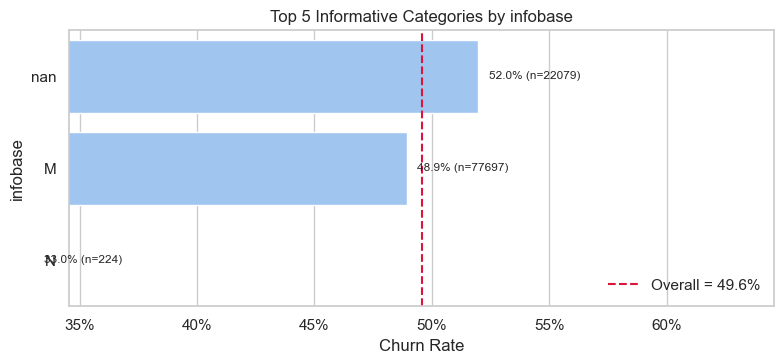


[dualband]
          count  churn_rate
dualband                   
N         23196    0.536817
Y         72265    0.487262
T          4316    0.421918
U           222    0.346847


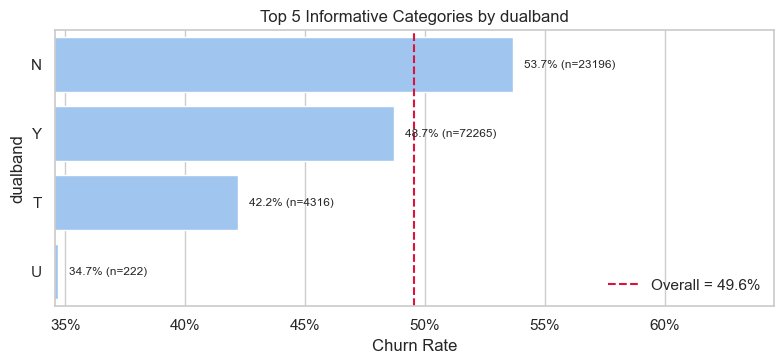


[hnd_webcap]
            count  churn_rate
hnd_webcap                   
NaN         10189    0.591520
WC          13843    0.563028
WCMB        75733    0.470799
UNKW          235    0.365957


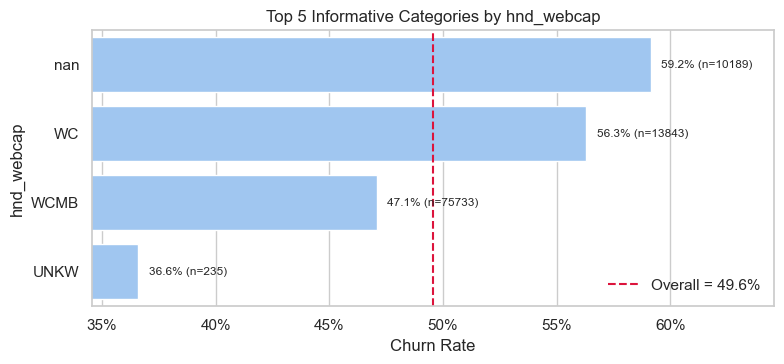


[asl_flag]
          count  churn_rate
asl_flag                   
N         86064    0.509598
Y         13936    0.409300


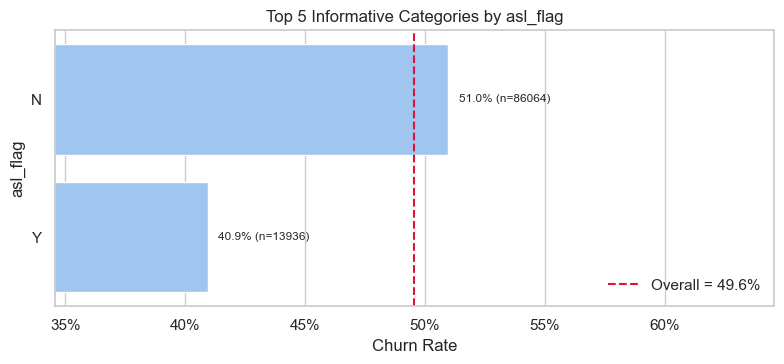


[refurb_new]
            count  churn_rate
refurb_new                   
R           14406    0.534361
N           85593    0.489105


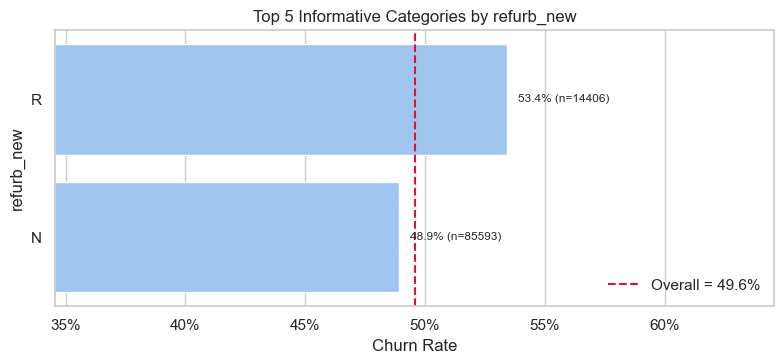


[prizm_social_one]
                  count  churn_rate
prizm_social_one                   
R                  4895    0.527068
NaN                7388    0.515701
T                 14989    0.508373
S                 32097    0.490762
U                 23613    0.484818


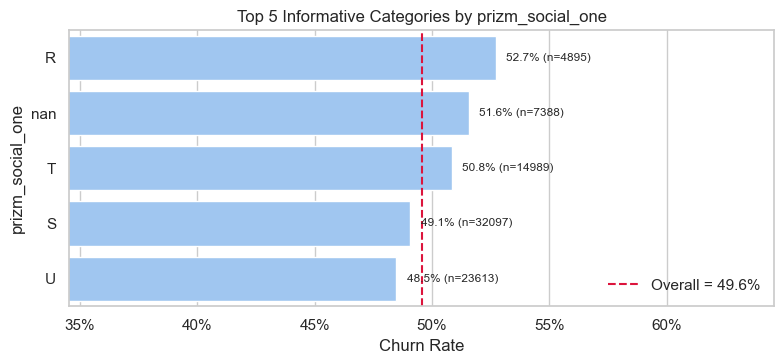


[hhstatin]
          count  churn_rate
hhstatin                   
H           923    0.522210
NaN       37923    0.509875
C         39124    0.486377
I         12352    0.480975
B          3246    0.479667


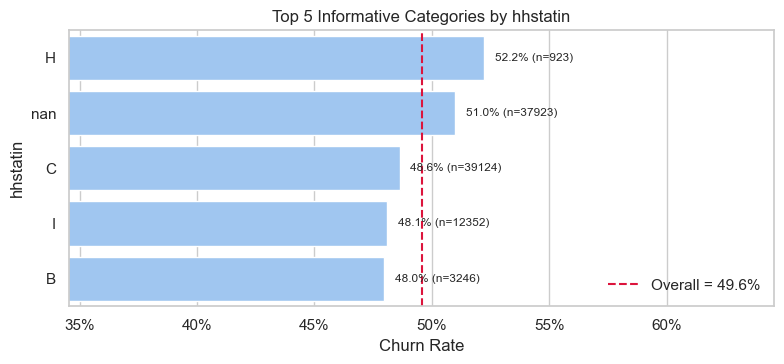


[kid0_2]
        count  churn_rate
kid0_2                   
Y        4012    0.519442
U       94256    0.494918
NaN      1732    0.478637


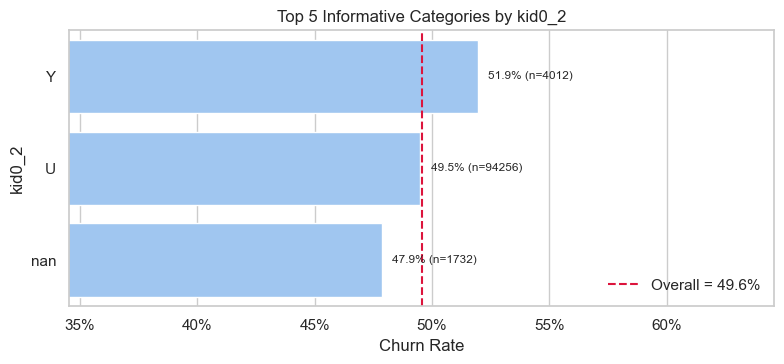

In [1735]:
# 2.6: Categorical vs Churn
if categorical_cols:
    # Cardinality summary
    cat_cardinality = df[categorical_cols].nunique(dropna=False).sort_values(ascending=False)
    print("Top categorical cardinality:")
    print(cat_cardinality.head(20))

    base_rate = df[target_col].mean()
    min_count = 50  # fixed threshold

    # Candidate categorical features (low cardinality)
    low_card_cats = [c for c in categorical_cols if df[c].nunique(dropna=False) <= 10]

    # Rank features by churn spread (max absolute deviation from overall churn rate)
    feature_spread = {}
    for c in low_card_cats:
        tmp_feat = (
            df.groupby(c, dropna=False)[target_col]
              .agg(["count", "mean"])
              .rename(columns={"mean": "churn_rate"})
        )
        tmp_feat = tmp_feat[tmp_feat["count"] >= min_count]
        if not tmp_feat.empty:
            feature_spread[c] = (tmp_feat["churn_rate"] - base_rate).abs().max()

    ranked_cats = sorted(feature_spread, key=feature_spread.get, reverse=True)[:8]

    for c in ranked_cats:
        tmp = (
            df.groupby(c, dropna=False)[target_col]
              .agg(["count", "mean"])
              .rename(columns={"mean": "churn_rate"})
        )

        # Filter small sample categories
        tmp = tmp[tmp["count"] >= min_count]
        if tmp.empty:
            print(f"\n[{c}] skipped (no categories with count >= {min_count})")
            continue

        # Top 5 most informative categories, then strictly sort by churn rate (desc)
        tmp["informativeness"] = (tmp["churn_rate"] - base_rate).abs()
        tmp = tmp.sort_values("informativeness", ascending=False).head(5)
        tmp = tmp.sort_values("churn_rate", ascending=False)

        print(f"\n[{c}]")
        print(tmp[["count", "churn_rate"]])

        plot_df = tmp.reset_index().assign(**{c: lambda d: d[c].astype(str)})
        order = plot_df[c].tolist()  # strict churn_rate-desc order

        plt.figure(figsize=(8, 3.8))
        ax = sns.barplot(
            data=plot_df,
            y=c,
            x="churn_rate",
            order=order,
            color="#93c5fd"
        )

        # Zoom x-axis around overall churn rate
        x_min = max(0.0, base_rate - 0.15)
        x_max = min(1.0, base_rate + 0.15)
        if x_max - x_min < 0.08:
            pad = 0.04
            x_min = max(0.0, x_min - pad)
            x_max = min(1.0, x_max + pad)
        ax.set_xlim(x_min, x_max)

        # Overall churn reference line
        ax.axvline(base_rate, color="crimson", linestyle="--", linewidth=1.5, label=f"Overall = {base_rate:.1%}")
        ax.legend(loc="lower right", frameon=False)

        plt.title(f"Top 5 Informative Categories by {c}")
        plt.xlabel("Churn Rate")
        plt.ylabel(c)

        # Show x-axis as percentages
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

        # Prevent label clipping: add margin + disable clipping on text
        ax.margins(x=0.10)
        span = x_max - x_min
        for p, (_, row) in zip(ax.patches, plot_df.iterrows()):
            w = p.get_width()
            y = p.get_y() + p.get_height() / 2
            x_text = w + span * 0.015
            ax.text(
                x_text, y,
                f"{w:.1%} (n={int(row['count'])})",
                va="center", ha="left", fontsize=8.5, clip_on=False
            )

        plt.tight_layout()
        plt.show()


### 2.7 Numeric vs Churn
Numeric features are contrasted by churn outcome to identify monotonic or non-linear separation patterns.

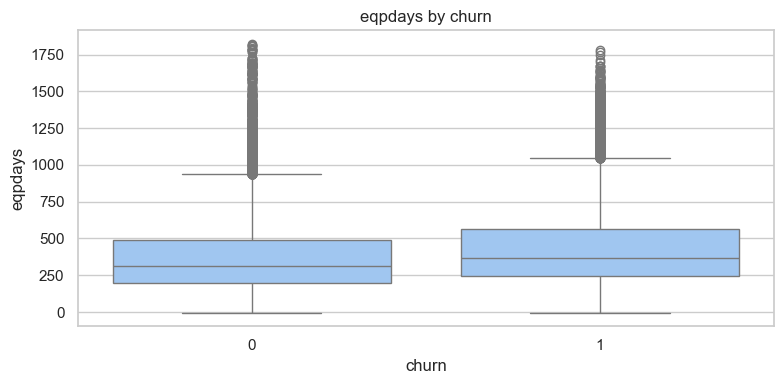

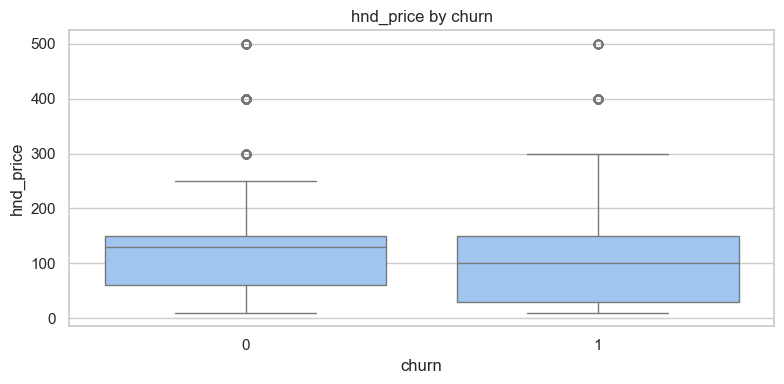

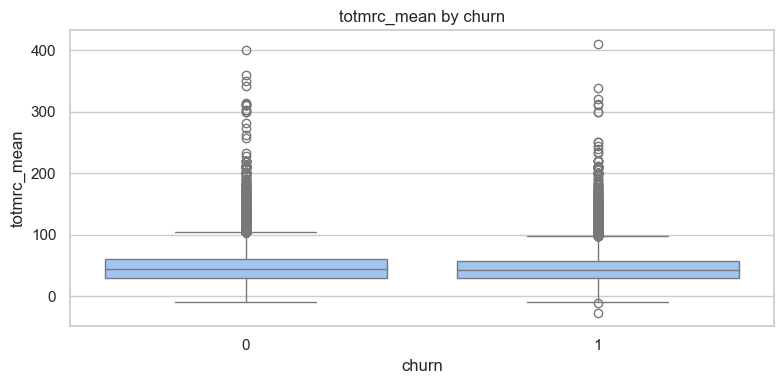

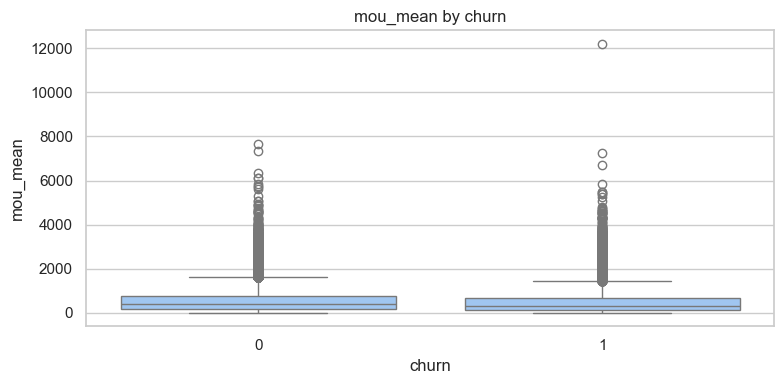

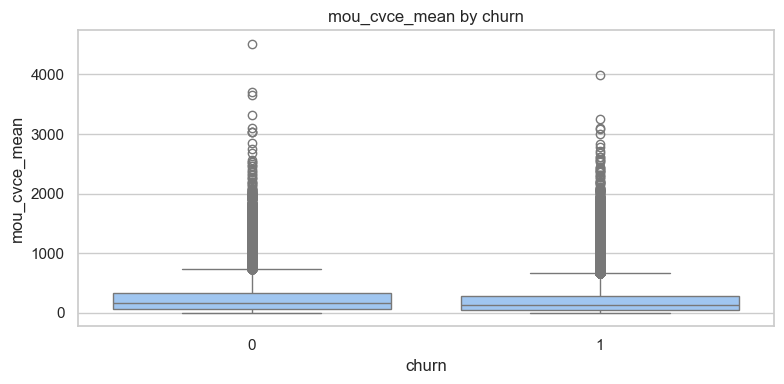

In [1736]:
# 2.7: Numeric vs Churn
num_no_target = [c for c in numeric_cols if c != target_col]

# Fallback: define top_corr_features if not already defined
if "top_corr_features" not in locals():
    target_corr = (
        df[num_no_target + [target_col]]
        .corr(numeric_only=True)[target_col]
        .drop(labels=[target_col], errors="ignore")
    )
    top_corr_features = target_corr.abs().sort_values(ascending=False).index.tolist()

# Use top 5 numeric features by absolute correlation with target_col
top5_num_vs_churn = [c for c in top_corr_features if c in num_no_target][:5]

for c in top5_num_vs_churn:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=target_col, y=c, color="#93c5fd")
    plt.title(f"{c} by {target_col}")
    plt.tight_layout()
    plt.show()



### 2.8 Outlier Diagnostics (IQR)
IQR-based outlier rates are computed and visualized to quantify tail behavior and potential robustness concerns.

In [1737]:
# 2.8 Outlier Diagnostics (IQR) - table
num_cols_iqr = [c for c in df.select_dtypes(include=["number"]).columns if c != TARGET_COL]

iqr_rows = []
for c in num_cols_iqr:
    s = pd.to_numeric(df[c], errors="coerce")
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    outlier_mask = (s < low) | (s > high)
    n_out = int(outlier_mask.sum())
    n_valid = int(s.notna().sum())
    outlier_pct = (n_out / n_valid * 100) if n_valid > 0 else 0.0

    iqr_rows.append({
        "feature": c,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": low,
        "upper_bound": high,
        "outlier_count": n_out,
        "outlier_pct": round(outlier_pct, 2)
    })

iqr_outlier_tbl = pd.DataFrame(iqr_rows).sort_values("outlier_pct", ascending=False)
display(iqr_outlier_tbl.head(20))


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
10,change_rev,-7.365,1.642500,9.007500,-20.87625,15.153750,25816,26.05
8,roam_mean,0.000,0.235000,0.235000,-0.35250,0.587500,18914,18.98
69,truck,0.000,0.000000,0.000000,0.00000,0.000000,18555,18.88
18,plcd_dat_mean,0.000,0.000000,0.000000,0.00000,0.000000,14980,14.98
47,callwait_mean,0.000,1.333333,1.333333,-2.00000,3.333333,14305,14.31
25,cc_mou_mean,0.000,2.873333,2.873333,-4.31000,7.183333,14265,14.27
7,datovr_mean,0.000,0.000000,0.000000,0.00000,0.000000,13673,13.72
9,change_mou,-87.000,63.000000,150.000000,-312.00000,288.000000,13490,13.61
24,ccrndmou_mean,0.000,4.000000,4.000000,-6.00000,10.000000,13456,13.46
22,comp_dat_mean,0.000,0.000000,0.000000,0.00000,0.000000,13393,13.39


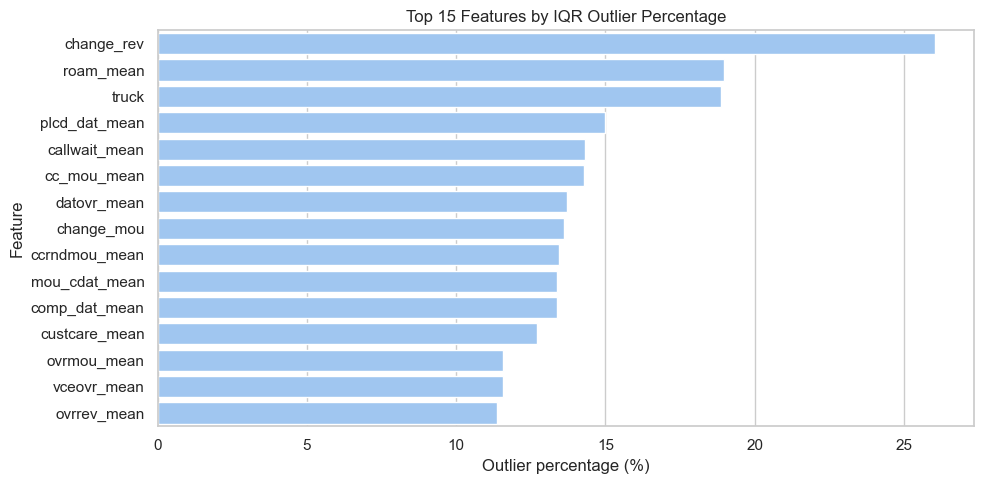

In [1738]:
# 2.8 Outlier Diagnostics (IQR) - plot

if "iqr_outlier_tbl" not in globals():
    raise ValueError("iqr_outlier_tbl is not defined. Run the previous IQR table cell first.")

plot_df = iqr_outlier_tbl.copy()

# Ensure outlier_pct is in percentage scale
if plot_df["outlier_pct"].max() <= 1.0:
    plot_df["outlier_pct"] = plot_df["outlier_pct"] * 100

top_n = 15
plot_df = plot_df.sort_values("outlier_pct", ascending=False).head(top_n)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="outlier_pct", y="feature", color="#93c5fd")
plt.title(f"Top {top_n} Features by IQR Outlier Percentage")
plt.xlabel("Outlier percentage (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### 2.9 Quick Risk Flags
A concise risk summary is produced to capture actionable EDA findings for modeling decisions.

In [1739]:
# 2.9: Quick Risk Flags
if num_no_target:
    # Use top 3 numeric features by absolute correlation with target_col
    risk_features = [c for c in top_corr_features if c in num_no_target][:3]

    for c in risk_features:
        try:
            binned = pd.qcut(df[c], q=5, duplicates="drop")
            risk = df.groupby(binned, dropna=False, observed=False)[target_col].mean().to_frame("churn_rate")
            print(f"\nChurn rate across {c} quantiles:")
            print(risk)
        except Exception:
            pass



Churn rate across eqpdays quantiles:
                 churn_rate
eqpdays                    
(-5.001, 188.0]    0.415325
(188.0, 300.0]     0.373817
(300.0, 395.0]     0.595278
(395.0, 589.0]     0.530401
(589.0, 1823.0]    0.563787
NaN                0.000000

Churn rate across hnd_price quantiles:
                  churn_rate
hnd_price                   
(9.989, 29.99]      0.574615
(29.99, 79.99]      0.508935
(79.99, 129.99]     0.464321
(129.99, 149.99]    0.468119
(149.99, 499.99]    0.410198
NaN                 0.367178

Churn rate across totmrc_mean quantiles:
                  churn_rate
totmrc_mean                 
(-26.916, 29.99]    0.552079
(29.99, 39.99]      0.520582
(39.99, 47.005]     0.453743
(47.005, 59.99]     0.488502
(59.99, 409.99]     0.436375
NaN                 0.686275


### 2.10 Numeric Correlation with Target
Correlation ranking is used as a fast signal check, not as the sole basis for feature selection.

In [1740]:
# 2.10: Numeric Correlation with Target
num_corr_features = [c for c in numeric_cols if c != target_col]
if num_corr_features:
    target_corr = (
        df[num_corr_features + [target_col]]
        .corr(numeric_only=True)[target_col]
        .drop(labels=[target_col], errors="ignore")
    )
    top_corr = (
        target_corr.to_frame("corr_with_target")
        .assign(abs_corr=lambda x: x["corr_with_target"].abs())
        .sort_values("abs_corr", ascending=False)
        .head(15)
    )
    print(top_corr[["corr_with_target"]])


               corr_with_target
eqpdays                0.112691
hnd_price             -0.103184
totmrc_mean           -0.068558
mou_mean              -0.057027
mou_cvce_mean         -0.052042
complete_mean         -0.051740
comp_vce_mean         -0.051574
avg3mou               -0.049546
mou_opkv_mean         -0.048896
attempt_mean          -0.048533
plcd_vce_mean         -0.048321
peak_vce_mean         -0.048320
opk_vce_mean          -0.047873
mou_peav_mean         -0.047287
mou_rvce_mean         -0.047148


## 3. Prepare the data
TData preparation is implemented with strict split discipline and a reproducible preprocessing pipeline. The workflow follows train/validation/test separation to prevent leakage from preprocessing, threshold selection, or model comparison. All parameter-learning preprocessing steps (imputation, scaling, encoding) are fit on training data only through the modeling pipeline. Additional audit checks are included to verify schema, labels, split consistency, feature typing, and transformed-matrix integrity.

In [1741]:

def standardize_col(col: str) -> str:
    col = col.strip().lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def check_matrix(name, M):
    if sparse.issparse(M):
        has_nan = np.isnan(M.data).any()
        has_inf = np.isinf(M.data).any()
        nnz = M.nnz
        total = M.shape[0] * M.shape[1]
        density = nnz / total if total else 0.0
        print(f"{name}: shape={M.shape}, sparse=True, nnz={nnz}, density={density:.6f}, has_nan={has_nan}, has_inf={has_inf}")
    else:
        has_nan = np.isnan(M).any()
        has_inf = np.isinf(M).any()
        print(f"{name}: shape={M.shape}, sparse=False, has_nan={has_nan}, has_inf={has_inf}")

def md5_file(path, chunk_size=1024 * 1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


### 3.1 Load cleaned/base data
Modeling input is loaded from a controlled path with fixed configuration parameters.

In [1742]:
# 3.1 Load cleaned/base data
df_model = pd.read_csv(DATA_PATH).copy()

### 3.2 Standardize columns
Column normalization is reapplied to ensure consistent naming across all downstream steps.

In [1743]:
# 3.2 Standardize columns
df_model.columns = [standardize_col(c) for c in df_model.columns]
TARGET_COL = standardize_col(TARGET_COL)

### 3.3 Confirmed leakage interface
A dedicated interface is retained to explicitly drop confirmed leakage columns if identified.

In [1744]:
# 3.3 Confirmed leakage interface
confirmed_leak_cols = []  # add explicit leakage columns here if known
confirmed_leak_cols = [c for c in confirmed_leak_cols if c in df_model.columns and c != TARGET_COL]
if confirmed_leak_cols:
    df_model = df_model.drop(columns=confirmed_leak_cols, errors="ignore")
print("Dropped confirmed leak cols:", confirmed_leak_cols if confirmed_leak_cols else "None")


Dropped confirmed leak cols: None


### 3.4 Drop ID-like cols
Identifier-like fields are removed conservatively to improve generalization and auditability.

In [1745]:
# 3.4 Drop ID-like cols
id_cols = [c for c in df_model.columns if c != TARGET_COL and (c == "id" or c.endswith("_id"))]
if id_cols:
    df_model = df_model.drop(columns=id_cols, errors="ignore")
print("Dropped ID-like cols:", id_cols if id_cols else "None")

Dropped ID-like cols: ['customer_id']


### 3.5 Validate target
Target integrity checks ensure binary validity and prevent silent training errors.

In [1746]:
# 3.5 Validate target
if TARGET_COL not in df_model.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found.")

if df_model[TARGET_COL].dtype == "O":
    s = df_model[TARGET_COL].astype(str).str.strip().str.lower()
    m = {"yes": 1, "no": 0, "true": 1, "false": 0, "1": 1, "0": 0}
    mapped = s.map(m)
    if mapped.notna().all():
        df_model[TARGET_COL] = mapped

df_model[TARGET_COL] = pd.to_numeric(df_model[TARGET_COL], errors="coerce")
df_model = df_model[df_model[TARGET_COL].notna()].copy()
df_model[TARGET_COL] = df_model[TARGET_COL].astype(int)

if set(df_model[TARGET_COL].unique()) != {0, 1}:
    raise ValueError(f"Target '{TARGET_COL}' must contain both classes 0 and 1.")


### 3.6 Clean object cols
Categorical text normalization is applied to reduce category fragmentation.

In [1747]:
# 3.6 Clean object cols
obj_cols = df_model.select_dtypes(include=["object"]).columns.tolist()
missing_tokens = {"", "nan", "none", "null"}
for c in obj_cols:
    s = df_model[c]
    s = s.where(s.isna(), s.astype(str).str.strip())
    s = s.mask(s.notna() & s.str.lower().isin(missing_tokens), np.nan)
    df_model[c] = s

### 3.7 Define features and target
Features and target are split explicitly for controlled pipeline input.

In [1748]:
# 3.7 Build X, y
X = df_model.drop(columns=[TARGET_COL]).copy()
y = df_model[TARGET_COL].copy()

assert TARGET_COL in df_model.columns, "Target missing."
assert X.shape[1] > 0, "No feature columns."
assert set(pd.Series(y).dropna().unique()).issubset({0, 1}), "Non-binary target."

print("Data shape:", df_model.shape)
print("Feature count:", X.shape[1])
print("Target prevalence:", round(float(pd.Series(y).mean()), 4))

Data shape: (100000, 99)
Feature count: 98
Target prevalence: 0.4956


### 3.8 Stratified split (70/15/15)
Train/validation/test sets are created with stratification to preserve class balance.

Shapes train/valid/test: (70000, 98) (15000, 98) (15000, 98)
Churn rate train/valid/test: 0.4956 0.4957 0.4956
Overlap train-valid: 0
Overlap train-test : 0
Overlap valid-test : 0


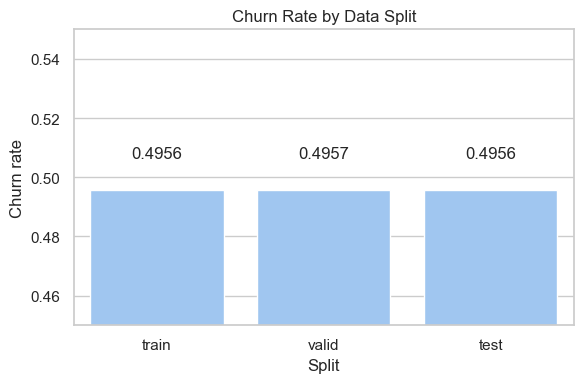

In [1749]:
# 3.8 Stratified split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print("Shapes train/valid/test:", X_train.shape, X_valid.shape, X_test.shape)
print("Churn rate train/valid/test:",
      round(float(pd.Series(y_train).mean()), 4),
      round(float(pd.Series(y_valid).mean()), 4),
      round(float(pd.Series(y_test).mean()), 4))

# split mutual exclusivity
train_idx, valid_idx, test_idx = set(X_train.index), set(X_valid.index), set(X_test.index)
print("Overlap train-valid:", len(train_idx & valid_idx))
print("Overlap train-test :", len(train_idx & test_idx))
print("Overlap valid-test :", len(valid_idx & test_idx))

# Split class balance plot
split_rates = pd.DataFrame({
    "split": ["train", "valid", "test"],
    "churn_rate": [y_train.mean(), y_valid.mean(), y_test.mean()]
})

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=split_rates, x="split", y="churn_rate", color="#93c5fd")
ax.set_title("Churn Rate by Data Split")
ax.set_xlabel("Split")
ax.set_ylabel("Churn rate")
ax.set_ylim(0.45, 0.55)

for i, v in enumerate(split_rates["churn_rate"]):
    ax.text(i, v + 0.01, f"{v:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### 3.9 Feature Types from Train
Feature typing is inferred from training data to avoid information leakage from holdout sets.

In [1750]:
# 3.9 Train-only high-missing drop
missing_pct_train = X_train.isna().mean() * 100
high_missing_cols = missing_pct_train[missing_pct_train > HIGH_MISSING_THRESHOLD].index.tolist()

if high_missing_cols:
    X_train = X_train.drop(columns=high_missing_cols, errors="ignore")
    X_valid = X_valid.drop(columns=high_missing_cols, errors="ignore")
    X_test = X_test.drop(columns=high_missing_cols, errors="ignore")

print("Dropped high-missing cols:", high_missing_cols if high_missing_cols else "None")

Dropped high-missing cols: ['numbcars']


### 3.10 Train-only constant drop
Constant features are identified from training data and removed consistently across splits.

In [1751]:
# 3.10 Preprocessing pipeline
constant_cols = [c for c in X_train.columns if X_train[c].nunique(dropna=False) <= 1]

if constant_cols:
    X_train = X_train.drop(columns=constant_cols, errors="ignore")
    X_valid = X_valid.drop(columns=constant_cols, errors="ignore")
    X_test = X_test.drop(columns=constant_cols, errors="ignore")

print("Dropped constant cols:", constant_cols if constant_cols else "None")


Dropped constant cols: None


### 3.11 Leakage-risk keyword scan
A stricter keyword/ID rule is used to generate a review list without noisy false positives.

In [1752]:
# 3.11 Leakage-risk keyword scan
# Use stricter ID rule to avoid false positives like kid0_2 / kid3_5
leak_terms = ("customer", "account", "phone", "target", "churn")

suspect_cols = []
for c in X_train.columns:
    cl = c.lower()
    is_id_like = (cl == "id") or cl.endswith("_id")
    has_leak_term = any(t in cl for t in leak_terms)
    if is_id_like or has_leak_term:
        suspect_cols.append(c)

suspect_cols = sorted(set(suspect_cols))

print("Leakage-risk keyword cols (review list):", suspect_cols if suspect_cols else "None")
print("Leakage keyword scan completed. Manual review performed for final keep/drop decisions.")


Leakage-risk keyword cols (review list): ['phones']
Leakage keyword scan completed. Manual review performed for final keep/drop decisions.


### 3.12 Feature typing
Final numerical/categorical feature lists are validated before pipeline construction.

In [1753]:
# 3.12 Feature typing
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]
print("Numeric feature count:", len(numeric_features))
print("Categorical feature count:", len(categorical_features))

Numeric feature count: 76
Categorical feature count: 21


### 3.13 Preprocessor
A `ColumnTransformer` is defined with `SimpleImputer + StandardScaler` for numeric and `SimpleImputer + OneHotEncoder` for categorical features.

In [1754]:
# 3.13 Preprocessor
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
], remainder="drop")

# class weights
classes = np.array([0, 1], dtype=int)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight_dict)

Class weights: {0: 0.9913048403999207, 1: 1.0088490473582568}


### 3.14 Preprocess output audit via clone(preprocessor)
A cloned preprocessor is audited to verify transformed outputs (shape/NaN/inf/sparsity) without contaminating model training.

In [1755]:
# 3.14 Preprocess output audit via clone(preprocessor)
audit_preprocessor = clone(preprocessor)
X_train_a = audit_preprocessor.fit_transform(X_train)
X_valid_a = audit_preprocessor.transform(X_valid)
X_test_a = audit_preprocessor.transform(X_test)

check_matrix("train_audit", X_train_a)
check_matrix("valid_audit", X_valid_a)
check_matrix("test_audit", X_test_a)

train_audit: shape=(70000, 228), sparse=False, has_nan=False, has_inf=False
valid_audit: shape=(15000, 228), sparse=False, has_nan=False, has_inf=False
test_audit: shape=(15000, 228), sparse=False, has_nan=False, has_inf=False


### 3.15 Save split artifacts with index
Split datasets and metadata are exported for traceability and reproducible reruns.

In [1756]:
# 3.15 Save split artifacts with index
split_dir = f"{OUTPUT_DIR}/splits"
X_train.to_csv(f"{split_dir}/X_train.csv", index=True)
X_valid.to_csv(f"{split_dir}/X_valid.csv", index=True)
X_test.to_csv(f"{split_dir}/X_test.csv", index=True)
y_train.to_csv(f"{split_dir}/y_train.csv", index=True)
y_valid.to_csv(f"{split_dir}/y_valid.csv", index=True)
y_test.to_csv(f"{split_dir}/y_test.csv", index=True)

pd.Series(high_missing_cols, name="dropped_high_missing").to_csv(f"{split_dir}/dropped_high_missing.csv", index=False)
pd.Series(constant_cols, name="dropped_constant").to_csv(f"{split_dir}/dropped_constant.csv", index=False)

### 3.16 Run manifest 
A manifest captures run configuration, data fingerprint, split sizes, and dropped columns for auditability.

In [1757]:
# 3.16 Run manifest 
data_path_obj = Path(DATA_PATH).resolve()
data_md5 = md5_file(data_path_obj)

manifest = {
    "run_timestamp": datetime.now().isoformat(timespec="seconds"),
    "random_seed": int(RANDOM_SEED),
    "data_path": str(data_path_obj),
    "data_file_md5": data_md5,
    "target_col": str(TARGET_COL),
    "input_shape": [int(df_model.shape[0]), int(df_model.shape[1])],
    "split_shapes": {
        "train": [int(X_train.shape[0]), int(X_train.shape[1])],
        "valid": [int(X_valid.shape[0]), int(X_valid.shape[1])],
        "test": [int(X_test.shape[0]), int(X_test.shape[1])]
    },
    "churn_rate": {
        "train": float(pd.Series(y_train).mean()),
        "valid": float(pd.Series(y_valid).mean()),
        "test": float(pd.Series(y_test).mean())
    },
    "high_missing_threshold": float(HIGH_MISSING_THRESHOLD),
    "dropped_high_missing_cols": [str(c) for c in high_missing_cols],
    "dropped_constant_cols": [str(c) for c in constant_cols],
    "suspect_cols_from_keyword_scan": [str(c) for c in suspect_cols]
}

with open(f"{OUTPUT_DIR}/run_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print(f"Saved: {OUTPUT_DIR}/run_manifest.json")

Saved: ../results/run_manifest.json


## 4. Explore different models and shortlist the best ones
This section establishes a baseline and compares multiple candidate models under the same preprocessing and split protocol. The shortlist decision is based on validation evidence rather than intuition. Compared candidates include a linear baseline (Logistic Regression), a tree ensemble (Random Forest), and a modern boosting model (XGBoost). This ensures methodological diversity and alignment with course expectations.


In [1758]:
print("Run timestamp:", datetime.now().isoformat(timespec="seconds"))
print("Seed:", RANDOM_SEED, "| Target:", TARGET_COL, "| Missing threshold:", HIGH_MISSING_THRESHOLD)


Run timestamp: 2026-03-09T06:50:18
Seed: 42 | Target: churn | Missing threshold: 40


In [1759]:
print("XGBoost OK")


XGBoost OK


### 4.1 Candidate model pipelines
Each model is wrapped in the same end-to-end pipeline (`preprocess -> model`) for fair and reproducible comparison.

In [1760]:
# 4.1 Candidate model pipelines
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "logistic_regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            solver="lbfgs",
            max_iter=2000,
            class_weight=class_weight_dict,
            random_state=RANDOM_SEED
        ))
    ]),
    "random_forest": Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight=class_weight_dict,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ]),
    "xgboost": Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight
        ))
    ])
}

### 4.2 Validation comparison
Models are first compared on validation at a fixed threshold (0.5) using ROC-AUC, PR-AUC, Precision, Recall, and F1.

In [1761]:
# 4.2 Validation comparison (fixed threshold = 0.5)
results_base = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    val_proba = model.predict_proba(X_valid)[:, 1]
    val_pred_05 = (val_proba >= 0.5).astype(int)

    fitted_models[name] = model

    results_base.append({
        "model": name,
        "threshold": 0.50,
        "accuracy": accuracy_score(y_valid, val_pred_05),
        "precision": precision_score(y_valid, val_pred_05, zero_division=0),
        "recall": recall_score(y_valid, val_pred_05, zero_division=0),
        "f1": f1_score(y_valid, val_pred_05, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, val_proba),
        "pr_auc": average_precision_score(y_valid, val_proba)
    })

results_base_df = pd.DataFrame(results_base).sort_values("f1", ascending=False).reset_index(drop=True)
display(results_base_df)

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,xgboost,0.5,0.640667,0.632982,0.654607,0.643613,0.699117,0.689308
1,random_forest,0.5,0.624600,0.617693,0.636718,0.627061,0.681371,0.664354
2,logistic_regression,0.5,0.597867,0.591568,0.609549,0.600424,0.629219,0.602608


### 4.3 Shortlist model using validation evidence
The final candidate for tuning is selected strictly from validation performance and trade-off suitability.

In [1762]:
# 4.3 Shortlist model using validation evidence
best_model_name = results_base_df.loc[0, "model"]
best_model = fitted_models[best_model_name]
print("Shortlisted model:", best_model_name)


Shortlisted model: xgboost


## 5. Fine-tune and evaluate
Fine-tuning is performed on validation data only, then locked for final test evaluation. The selected threshold is not retuned on test, preserving an unbiased final estimate. Evaluation includes both threshold-dependent and threshold-independent metrics, plus error-analysis views (confusion matrix, decile lift, calibration) to assess operational behavior and probability quality.

### 5.1 Tuning strategy
A threshold grid search on validation predictions is used to maximize F1 for the shortlisted model.

In [1763]:
# 5.1 Tuning strategy
threshold_grid = np.arange(0.05, 0.951, 0.01)

val_proba_best = best_model.predict_proba(X_valid)[:, 1]
f1_scores = [f1_score(y_valid, (val_proba_best >= t).astype(int), zero_division=0) for t in threshold_grid]

best_idx = int(np.argmax(f1_scores))
best_threshold = float(threshold_grid[best_idx])

print("Best threshold (validation):", best_threshold)
print("Best validation F1:", max(f1_scores))


Best threshold (validation): 0.3400000000000001
Best validation F1: 0.6888729947890059


### 5.2 Locked final test evaluation
The validation-selected threshold is fixed and applied once on test for final reporting.

In [1764]:
# 5.2 Locked final test evaluation
test_proba = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

test_metrics = {
    "selected_model": best_model_name,
    "selected_threshold": round(best_threshold, 2),
    "test_accuracy": round(accuracy_score(y_test, test_pred), 4),
    "test_precision": round(precision_score(y_test, test_pred, zero_division=0), 4),
    "test_recall": round(recall_score(y_test, test_pred, zero_division=0), 4),
    "test_f1": round(f1_score(y_test, test_pred, zero_division=0), 4),
    "test_roc_auc": round(roc_auc_score(y_test, test_proba), 4),
    "test_pr_auc": round(average_precision_score(y_test, test_proba), 4)
}
display(pd.DataFrame([test_metrics]))

print("Test Confusion Matrix:")
print(confusion_matrix(y_test, test_pred))


,selected_model,selected_threshold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,xgboost,0.34,0.591,0.5535,0.9046,0.6868,0.6913,0.678


Test Confusion Matrix:
[[2140 5426]
 [ 709 6725]]


### 5.3 Error analysis: decile lift / gains
Decile analysis evaluates ranking usefulness by showing concentration of churn risk in top-score buckets.

In [1765]:
# 5.3 Error analysis: decile lift / gains
eval_df = pd.DataFrame({"y": y_test.values, "proba": test_proba})
eval_df["decile"] = pd.qcut(eval_df["proba"], 10, labels=False, duplicates="drop")

decile_tbl = (
    eval_df.groupby("decile")
           .agg(n=("y", "size"), churn_rate=("y", "mean"), avg_score=("proba", "mean"))
           .sort_index(ascending=False)
)

overall_rate = eval_df["y"].mean()
top_decile_rate = decile_tbl.iloc[0]["churn_rate"] if len(decile_tbl) > 0 else np.nan
lift_top_decile = top_decile_rate / overall_rate if overall_rate > 0 else np.nan

print("Overall churn rate:", round(float(overall_rate), 4))
print("Top-decile churn rate:", round(float(top_decile_rate), 4))
print("Top-decile lift:", round(float(lift_top_decile), 4))
display(decile_tbl)


Overall churn rate: 0.4956
Top-decile churn rate: 0.7847
Top-decile lift: 1.5833


,n,churn_rate,avg_score
decile,,,
9,1500,0.784667,0.786231
8,1500,0.679333,0.680596
7,1500,0.593333,0.622116
6,1500,0.564000,0.573461
5,1500,0.552667,0.529055
4,1500,0.464667,0.484189
3,1500,0.425333,0.436538
2,1500,0.384667,0.379256
1,1500,0.308667,0.306565


### 5.4 Error analysis: calibration
Calibration curve checks whether predicted probabilities align with observed frequencies.

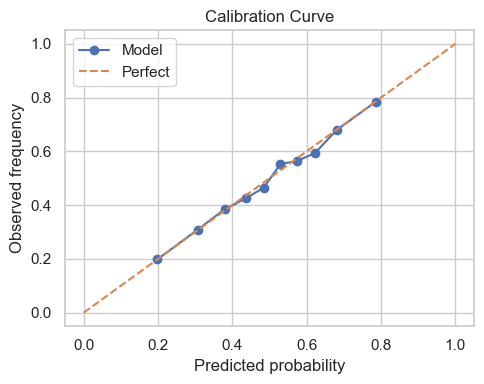

In [1766]:
# 5.4 Error analysis: calibration
frac_pos, mean_pred = calibration_curve(y_test, test_proba, n_bins=10, strategy="quantile")

plt.figure(figsize=(5, 4))
plt.plot(mean_pred, frac_pos, marker="o", label="Model")
plt.plot([0, 1], [0, 1], "--", label="Perfect")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/calibration_curve.png", dpi=200, bbox_inches="tight")
plt.show()

### 5.5 Save key outputs
Validation comparison, final test metrics, and error-analysis artifacts are exported for reporting and reproducibility.

In [1767]:
# 5.5 Save key outputs
results_base_df.to_csv(f"{OUTPUT_DIR}/validation_results.csv", index=False)
pd.DataFrame([test_metrics]).to_csv(f"{OUTPUT_DIR}/test_metrics.csv", index=False)
decile_tbl.to_csv(f"{OUTPUT_DIR}/decile_lift_table.csv")

print("Saved:")
print(f"- {OUTPUT_DIR}/validation_results.csv")
print(f"- {OUTPUT_DIR}/test_metrics.csv")
print(f"- {OUTPUT_DIR}/decile_lift_table.csv")
print(f"- {OUTPUT_DIR}/calibration_curve.png")

Saved:
- ../results/validation_results.csv
- ../results/test_metrics.csv
- ../results/decile_lift_table.csv
- ../results/calibration_curve.png


## 6. Present the final solution
The final selected model is **XGBoost** with a validation-selected threshold of **0.34**. On test, it achieved **Accuracy = 0.5910**, **Precision = 0.5535**, **Recall = 0.9046**, **F1 = 0.6868**, **ROC-AUC = 0.6913**, and **PR-AUC = 0.6780**. This operating point prioritizes churn capture (high recall), which is appropriate when missing true churners is costly. The main trade-off is increased false positives and intervention cost. The model is suitable for retention prioritization and triage, but not as a fully automated decision engine.

### 6.1 Final solution
Use this model as a ranking-and-targeting tool for retention campaigns. Keep threshold policy fixed unless revalidated, and monitor drift, calibration stability, and business cost impact over time.

In [1768]:
# 6.1 Final solution
final_summary = pd.DataFrame([{
    "selected_model": best_model_name,
    "selected_threshold": round(best_threshold, 2),
    "test_accuracy": round(accuracy_score(y_test, test_pred), 4),
    "test_precision": round(precision_score(y_test, test_pred, zero_division=0), 4),
    "test_recall": round(recall_score(y_test, test_pred, zero_division=0), 4),
    "test_f1": round(f1_score(y_test, test_pred, zero_division=0), 4),
    "test_roc_auc": round(roc_auc_score(y_test, test_proba), 4),
    "test_pr_auc": round(average_precision_score(y_test, test_proba), 4)
}])

display(final_summary)


,selected_model,selected_threshold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,xgboost,0.34,0.591,0.5535,0.9046,0.6868,0.6913,0.678
